In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_csv("/content/pakistan_weather_2000_2024.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31779 entries, 0 to 31778
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                31779 non-null  object 
 1   year                31779 non-null  int64  
 2   month               31779 non-null  int64  
 3   day                 31779 non-null  int64  
 4   dayofweek           31779 non-null  int64  
 5   is_weekend          31779 non-null  int64  
 6   season              31779 non-null  object 
 7   city                31779 non-null  object 
 8   region              31779 non-null  object 
 9   latitude            31779 non-null  float64
 10  longitude           31779 non-null  float64
 11  elevation           31779 non-null  int64  
 12  tmin                31779 non-null  float64
 13  tmax                31779 non-null  float64
 14  tavg                31779 non-null  float64
 15  prcp                31779 non-null  float64
 16  wspd

In [6]:
df.isnull().sum()

,0
date,0
year,0
month,0
day,0
dayofweek,0
is_weekend,0
season,0
city,0
region,0
latitude,0


In [7]:
df.describe()

,year,month,day,dayofweek,is_weekend,latitude,longitude,elevation,tmin,tmax,...,prcp,wspd,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day
count,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,...,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,0.0,31779.000000,31779.000000,31779.000000
mean,2011.103370,6.522609,15.730577,3.000063,0.285818,31.759637,71.239903,651.656817,15.186488,25.787577,...,1.717801,12.902307,58.138614,1010.829195,10.129120,32.852104,NaN,10.601089,0.009755,0.067340
std,7.176794,3.448845,8.800627,2.000267,0.451810,3.653211,2.976196,590.625245,9.613917,9.814480,...,5.971060,7.857757,18.456379,8.481143,10.263861,30.246910,NaN,3.787311,0.098285,0.250614
min,2000.000000,1.000000,1.000000,0.000000,0.000000,24.860700,66.975000,8.000000,-21.300000,-12.900000,...,0.000000,0.800000,6.000000,989.700000,-28.700000,0.000000,NaN,0.700000,0.000000,0.000000
25%,2005.000000,4.000000,8.000000,1.000000,0.000000,30.179800,67.001100,217.000000,8.100000,19.700000,...,0.000000,7.900000,45.000000,1004.000000,3.700000,5.000000,NaN,7.800000,0.000000,0.000000
50%,2010.000000,7.000000,16.000000,3.000000,0.000000,33.684400,73.047900,540.000000,16.700000,28.500000,...,0.000000,11.300000,61.000000,1011.400000,10.300000,25.000000,NaN,10.500000,0.000000,0.000000
75%,2017.000000,10.000000,23.000000,5.000000,1.000000,34.015100,73.047900,1500.000000,23.500000,32.800000,...,0.500000,16.800000,73.000000,1016.800000,18.800000,55.000000,NaN,13.400000,0.000000,0.000000
max,2024.000000,12.000000,31.000000,6.000000,1.000000,35.922100,74.343600,1680.000000,32.600000,47.300000,...,201.100000,50.600000,96.000000,1042.900000,27.500000,100.000000,NaN,22.500000,1.000000,1.000000


In [8]:
print(df.isnull().sum())

date                      0
year                      0
month                     0
day                       0
dayofweek                 0
is_weekend                0
season                    0
city                      0
region                    0
latitude                  0
longitude                 0
elevation                 0
tmin                      0
tmax                      0
tavg                      0
prcp                      0
wspd                      0
humidity                  0
pressure                  0
dew_point                 0
cloud_cover               0
visibility            31779
temp_range                0
is_hot_day                0
is_cold_day               0
rainfall_intensity        0
wind_category             0
dtype: int64


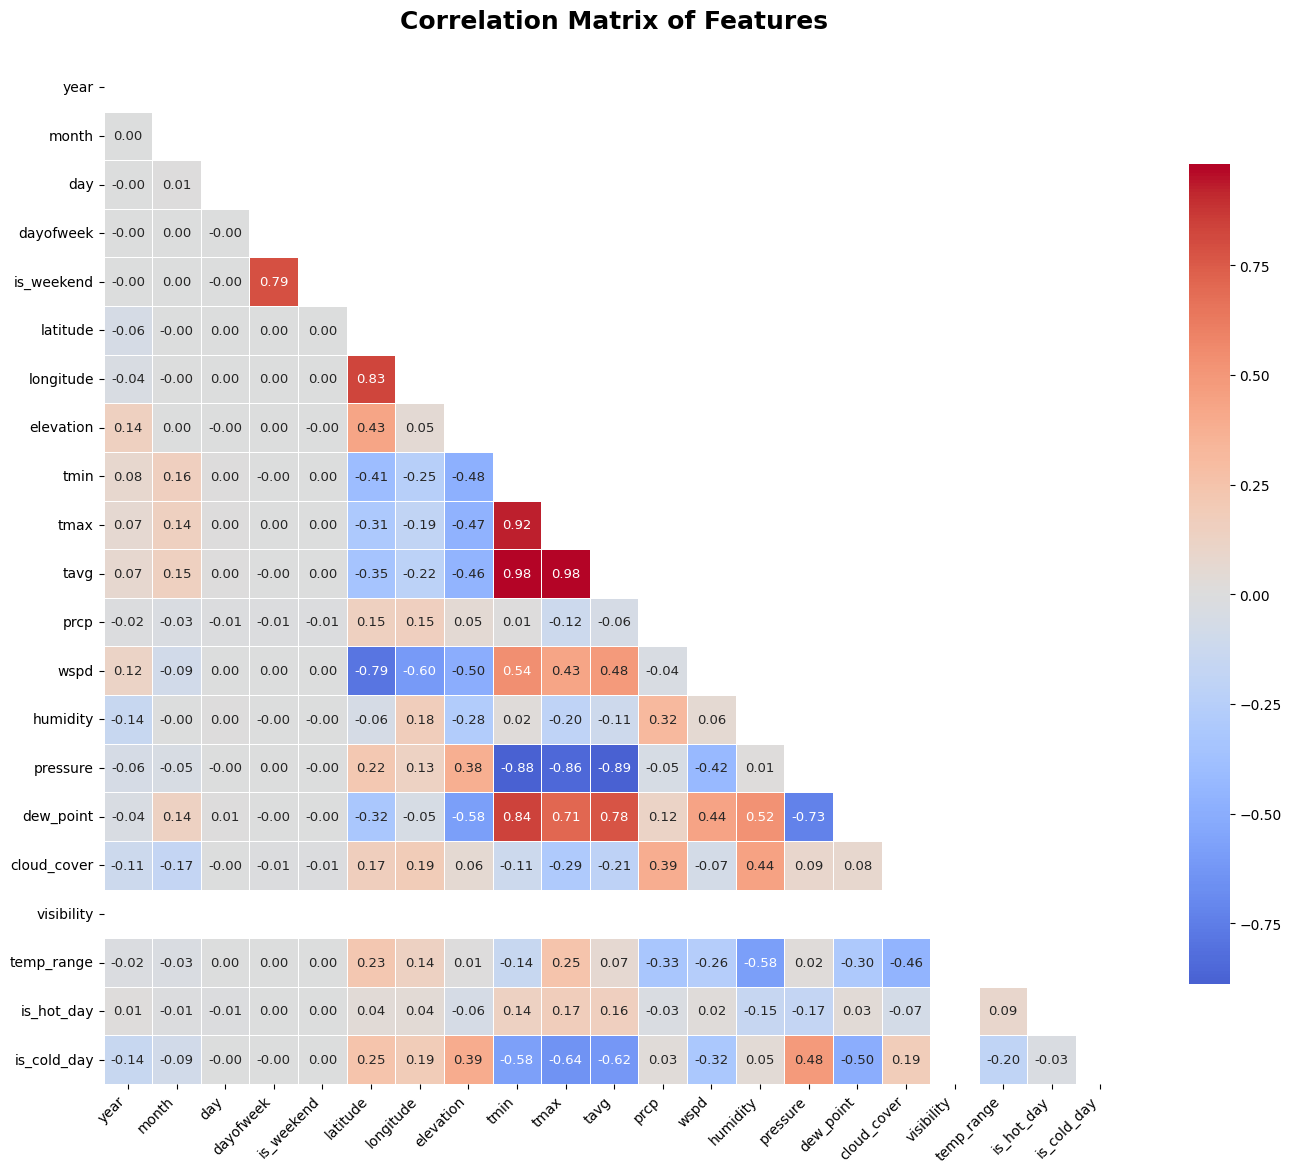

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(corr, dtype=bool))  # Optional: mask upper triangle

sns.heatmap(
    corr,
    mask=mask,                     # Show only lower triangle (cleaner look)
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 9.5}
)

plt.title('Correlation Matrix of Features', fontsize=18, pad=25, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
df.head()

,date,year,month,day,dayofweek,is_weekend,season,city,region,latitude,...,humidity,pressure,dew_point,cloud_cover,visibility,temp_range,is_hot_day,is_cold_day,rainfall_intensity,wind_category
0,2000-01-01,2000,1,1,5,1,Winter,Islamabad,Punjab,33.6844,...,76,1018.9,4.8,0,NaN,14.1,0,0,none,windy
9132,2000-01-01,2000,1,1,5,1,Winter,Karachi,Sindh,24.8607,...,33,1015.2,2.4,0,NaN,10.6,0,0,none,windy
27396,2000-01-01,2000,1,1,5,1,Winter,Gilgit,Gilgit-Baltistan,35.9221,...,56,1027.4,-10.3,0,NaN,11.9,0,1,none,breezy
18264,2000-01-01,2000,1,1,5,1,Winter,Peshawar,KPK,34.0151,...,68,1019.2,4.7,0,NaN,13.1,0,0,none,windy
9133,2000-01-02,2000,1,2,6,1,Winter,Karachi,Sindh,24.8607,...,37,1015.6,4.4,1,NaN,10.9,0,0,none,windy


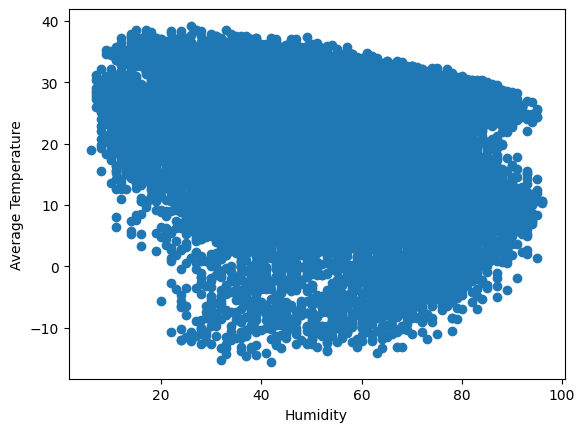

In [13]:
plt.scatter(df['humidity'], df['tavg'])
plt.xlabel("Humidity")
plt.ylabel("Average Temperature")
plt.show()

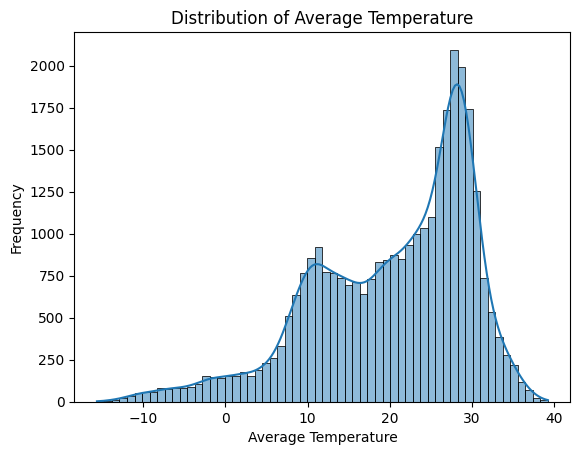

In [15]:
sns.histplot(df['tavg'], kde=True)
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Average Temperature")
plt.show()

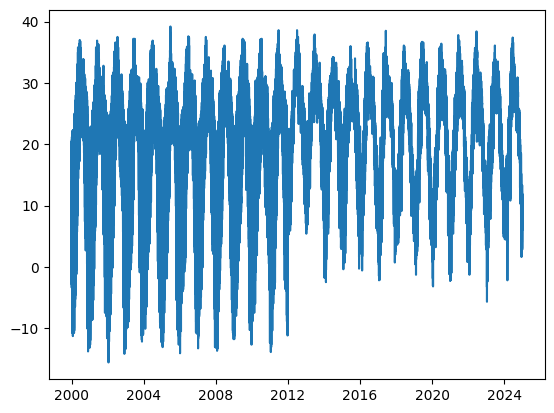

In [19]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

plt.plot(df['date'], df['tavg'])
plt.show()

In [21]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

In [26]:
X = df.drop(columns=['tavg', 'visibility'])   # features
y = df['tavg']                 # target

In [28]:
X = X.select_dtypes(include=[np.number])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 0.21
R-squared: 1.00


In [33]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.21470273176601426
RMSE: 0.4633602613151178
R2 Score: 0.9976980747457359


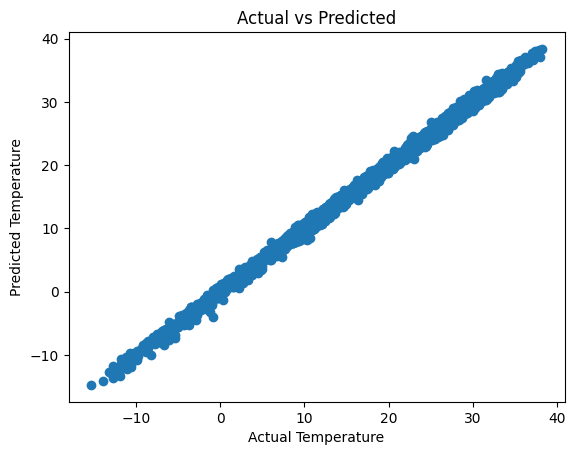

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.show()

In [36]:
X = df[['humidity', 'wspd', 'pressure']]
y = df['tavg']

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.8141856992869428
RMSE: 4.163060707204189
